# Crime Data Analysis — Los Angeles (2020–2024)
**Phase:** Data Cleaning & Preprocessing  
**Dataset:** 1,004,894 records · 28 features


## 1. Setup & Load Data

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv
import os

In [3]:
from pathlib import Path

load_dotenv()

DATA_PATH = os.getenv("DATA_PATH")

pd.set_option('display.max_columns', None)
file_path = Path(DATA_PATH) / "Crime_Data_from_2020_to_2024.csv" # type: ignore
df = pd.read_csv(file_path)

In [4]:
df.head()

,DR_NO,Date Rptd,DATE OCC,TIME OCC,AREA,AREA NAME,Rpt Dist No,Part 1-2,Crm Cd,Crm Cd Desc,Mocodes,Vict Age,Vict Sex,Vict Descent,Premis Cd,Premis Desc,Weapon Used Cd,Weapon Desc,Status,Status Desc,Crm Cd 1,Crm Cd 2,Crm Cd 3,Crm Cd 4,LOCATION,Cross Street,LAT,LON
0,211507896,04/11/2021 12:00:00 AM,11/07/2020 12:00:00 AM,845,15,N Hollywood,1502,2,354,THEFT OF IDENTITY,0377,31,M,H,501.0,SINGLE FAMILY DWELLING,NaN,NaN,IC,Invest Cont,354.0,NaN,NaN,NaN,7800 BEEMAN AV,NaN,34.2124,-118.4092
1,201516622,10/21/2020 12:00:00 AM,10/18/2020 12:00:00 AM,1845,15,N Hollywood,1521,1,230,"ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT",0416 0334 2004 1822 1414 0305 0319 0400,32,M,H,102.0,SIDEWALK,200.0,KNIFE WITH BLADE 6INCHES OR LESS,IC,Invest Cont,230.0,NaN,NaN,NaN,ATOLL AV,N GAULT,34.1993,-118.4203
2,240913563,12/10/2024 12:00:00 AM,10/30/2020 12:00:00 AM,1240,9,Van Nuys,933,2,354,THEFT OF IDENTITY,0377,30,M,W,501.0,SINGLE FAMILY DWELLING,NaN,NaN,IC,Invest Cont,354.0,NaN,NaN,NaN,14600 SYLVAN ST,NaN,34.1847,-118.4509
3,210704711,12/24/2020 12:00:00 AM,12/24/2020 12:00:00 AM,1310,7,Wilshire,782,1,331,THEFT FROM MOTOR VEHICLE - GRAND ($950.01 AND ...,0344,47,F,A,101.0,STREET,NaN,NaN,IC,Invest Cont,331.0,NaN,NaN,NaN,6000 COMEY AV,NaN,34.0339,-118.3747
4,201418201,10/03/2020 12:00:00 AM,09/29/2020 12:00:00 AM,1830,14,Pacific,1454,1,420,THEFT FROM MOTOR VEHICLE - PETTY ($950 & UNDER),1300 0344 1606 2032,63,M,H,103.0,ALLEY,NaN,NaN,IC,Invest Cont,420.0,NaN,NaN,NaN,4700 LA VILLA MARINA,NaN,33.9813,-118.4350


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1004894 entries, 0 to 1004893
Data columns (total 28 columns):
 #   Column          Non-Null Count    Dtype  
---  ------          --------------    -----  
 0   DR_NO           1004894 non-null  int64  
 1   Date Rptd       1004894 non-null  object 
 2   DATE OCC        1004894 non-null  object 
 3   TIME OCC        1004894 non-null  int64  
 4   AREA            1004894 non-null  int64  
 5   AREA NAME       1004894 non-null  object 
 6   Rpt Dist No     1004894 non-null  int64  
 7   Part 1-2        1004894 non-null  int64  
 8   Crm Cd          1004894 non-null  int64  
 9   Crm Cd Desc     1004894 non-null  object 
 10  Mocodes         853296 non-null   object 
 11  Vict Age        1004894 non-null  int64  
 12  Vict Sex        860263 non-null   object 
 13  Vict Descent    860251 non-null   object 
 14  Premis Cd       1004878 non-null  float64
 15  Premis Desc     1004306 non-null  object 
 16  Weapon Used Cd  327216 non-null   fl

#### Observations
- The dataset contains **1,004,894 records** and **28 features** covering Los Angeles crime incidents from 2020 to 2024.
- Column names use inconsistent casing and abbreviations (e.g. `Crm Cd`, `Vict Age`). Renaming is the first priority.
- Several columns have mixed or incorrect dtypes that will need correction throughout this phase.


## 1 — Column Renaming

In [6]:
columns_to_rename = {
    'Date Rptd': 'reported_date',
    'TIME OCC': 'time_occurrence',
    'DATE OCC': 'date_occurrence',
    'AREA': 'area_code',
    'AREA NAME': 'area_name',
    'Part 1-2' : 'crime_part',
    'Rpt Dist No': 'reported_district_number',
    'Crm Cd': 'crime_code',
    'Crm Cd Desc': 'crime_code_description',
    'Premis Cd': 'premise_code',
    'Premis Desc': 'premise_description',
    'Weapon Used Cd': 'weapon_used_code',
    'Weapon Desc': 'weapon_description',
    'status Desc': 'status_description',
    'Crm Cd 1': 'crime_code_1',
    'Crm Cd 2': 'crime_code_2',
    'Cross Street':'cross_street',
    'LOCATION':'location',
    'Status' : 'status',
    'Status Desc' : 'status_description',
    'Crm Cd 3': 'crime_code_3',
    'Crm Cd 4': 'crime_code_4',
    'Vict Age': 'victim_age',
    'Vict Sex': 'victim_sex',
    'Vict Descent': 'victim_descent',
    'LAT': 'latitude',
    'LON': 'longitude',
}
df.rename(columns=columns_to_rename, inplace=True)
df.columns

Index(['DR_NO', 'reported_date', 'date_occurrence', 'time_occurrence',
       'area_code', 'area_name', 'reported_district_number', 'crime_part',
       'crime_code', 'crime_code_description', 'Mocodes', 'victim_age',
       'victim_sex', 'victim_descent', 'premise_code', 'premise_description',
       'weapon_used_code', 'weapon_description', 'status',
       'status_description', 'crime_code_1', 'crime_code_2', 'crime_code_3',
       'crime_code_4', 'location', 'cross_street', 'latitude', 'longitude'],
      dtype='object')

#### Observations
- All 23 columns were renamed from raw LAPD abbreviations (e.g. `Crm Cd Desc`, `Vict Sex`) to clean `snake_case` names that are more readable and consistent.
- The rename map covers both date columns, victim info, crime codes, weapon fields, and geographic identifiers.
- The remaining columns not in the map (`DR_NO`, `Mocodes`, `Part 1-2`, `Status`, `Cross Street`) retain their original names until addressed in subsequent steps.


## 2 — Drop Identifier Column

In [7]:
# Drop Identifier Column (Useless in Analysis)
df.drop(columns=['DR_NO'], inplace=True)

#### Observations
- `DR_NO` (Division of Records Number) is a unique administrative identifier assigned by LAPD for internal record tracking.
- It carries no analytical signal — it does not encode crime type, location, time, or any demographic attribute.
- Dropping it reduces the feature space by one column and prevents it from accidentally being used as a feature in downstream modeling.


## 3 — Parse & Validate Date Columns

In [8]:
df[['date_occurrence', 'reported_date']].dtypes

date_occurrence    object
reported_date      object
dtype: object

In [9]:
df['reported_date'] = pd.to_datetime(df['reported_date'],  format='mixed')
df['date_occurrence'] = pd.to_datetime(df['date_occurrence'],  format='mixed')
df[['date_occurrence', 'reported_date']].dtypes

date_occurrence    datetime64[ns]
reported_date      datetime64[ns]
dtype: object

In [10]:
df['reported_date'].head()

0   2021-04-11
1   2020-10-21
2   2024-12-10
3   2020-12-24
4   2020-10-03
Name: reported_date, dtype: datetime64[ns]

In [11]:
print(df.loc[0, 'reported_date'])
print(df.loc[0, 'date_occurrence'])

2021-04-11 00:00:00
2020-11-07 00:00:00


In [12]:
df[(df['reported_date'] < df['date_occurrence'])]

,reported_date,date_occurrence,time_occurrence,area_code,area_name,reported_district_number,crime_part,crime_code,crime_code_description,Mocodes,victim_age,victim_sex,victim_descent,premise_code,premise_description,weapon_used_code,weapon_description,status,status_description,crime_code_1,crime_code_2,crime_code_3,crime_code_4,location,cross_street,latitude,longitude


#### Observations
- `reported_date` and `date_occurrence` were originally stored as `object` (string). Both are now cast to `datetime64` using `format='mixed'` to handle any inconsistent date formats in the source CSV.
- A validation check confirms **zero records** where `reported_date < date_occurrence` — meaning no crime was reported before it occurred, which is the expected logical constraint. The data passes this sanity check.
- Both columns contain no missing values, making them reliable anchors for any time-series or temporal analysis in later phases.


## 4 — `area_code` → `int8`

In [13]:
# use int8 for area code.
df['area_code'] = df['area_code'].astype('int8')

#### Observations
- LAPD divides the city into **21 geographic areas**, meaning `area_code` only ever holds integer values from 1 to 21.
- `int8` supports values from -128 to 127, which is more than sufficient and reduces memory usage by **75%** compared to the default `int64`.


## `time_occurrence` into Hour & Minute

In [14]:
# Convert time_occurrence to hour and minute columns.
df['time_occurrence'] = df['time_occurrence'].apply(lambda x: f"{x:04d}")
df['hour_occurrence'] = df['time_occurrence'].str[:2].astype('int8')
df['minute_occurrence'] = df['time_occurrence'].str[2:].astype('int8')
df[['time_occurrence', 'hour_occurrence', 'minute_occurrence']].head()

# remove time_occurrence after extracting
df.drop(columns=['time_occurrence'], inplace=True)

#### Observations
- `time_occurrence` is stored as a 4-digit integer (e.g. `1430` for 2:30 PM). It is zero-padded to a string before splitting.
- Two new columns are derived: `hour_occurrence` (0–23) and `minute_occurrence` (0–59), both stored as `int8` for memory efficiency.
- This split makes time-of-day analysis straightforward — hourly crime distribution, peak hours, and shift-based patterns can now be computed directly without string parsing at analysis time.


## name` → Category

In [15]:
df['area_name'] = df['area_name'].astype('category')
df['area_name'].unique()

['N Hollywood', 'Van Nuys', 'Wilshire', 'Pacific', 'Hollenbeck', ..., 'Central', 'West LA', '77th Street', 'West Valley', 'Harbor']
Length: 21
Categories (21, object): ['77th Street', 'Central', 'Devonshire', 'Foothill', ..., 'Van Nuys', 'West LA', 'West Valley', 'Wilshire']

#### Observations
- `area_name` contains exactly **21 unique string values**, one per LAPD geographic area (e.g. `Hollywood`, `Newton`, `Pacific`).
- Converting to `category` dtype replaces repeated strings with integer codes internally, significantly reducing memory for a column with ~1M rows of only 21 distinct values.
- This also enables faster `groupby` and filtering operations in later analysis.


## crime_part` → `Boolean`

In [16]:
# Covert crime_part to boolean
df['crime_part'] = df['crime_part'] == 1
# part 1 = True else = False

#### Observations
- `crime_part` classifies crimes by FBI severity: **Part 1** = serious crimes (homicide, robbery, assault, burglary, etc.), **Part 2** = less serious offenses.
- The column originally holds integer values `1` or `2`. Casting to `boolean` is appropriate since only two values are ever present.


## reported_district_number` → `int32`

In [17]:
df['reported_district_number'] = df['reported_district_number'].astype('int32')

In [18]:
duplicates_count = df.duplicated().sum()
print(f"Duplicates Count: {duplicates_count}")

# dropping Duplicates forws
df = df.drop_duplicates()

print(f"Duplicates Count After Dropping: {df.duplicated().sum()}")

Duplicates Count: 2965
Duplicates Count After Dropping: 0


#### Observations
- `reported_district_number` holds 4-digit reporting district codes (e.g. `101`, `1822`). Values fit comfortably within `int32` range.
- `int32` is chosen over `int8`/`int16` because district codes can exceed 255, but `int64` (the default) would be unnecessarily large.

## ormalize `crime_code_description`

In [19]:
df['crime_code_description'] = df['crime_code_description'].str.lower()
df['crime_code_description'] = df['crime_code_description'].astype('string[pyarrow]') # better for memory

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1001929 entries, 0 to 1004893
Data columns (total 28 columns):
 #   Column                    Non-Null Count    Dtype         
---  ------                    --------------    -----         
 0   reported_date             1001929 non-null  datetime64[ns]
 1   date_occurrence           1001929 non-null  datetime64[ns]
 2   area_code                 1001929 non-null  int8          
 3   area_name                 1001929 non-null  category      
 4   reported_district_number  1001929 non-null  int32         
 5   crime_part                1001929 non-null  bool          
 6   crime_code                1001929 non-null  int64         
 7   crime_code_description    1001929 non-null  string        
 8   Mocodes                   851580 non-null   object        
 9   victim_age                1001929 non-null  int64         
 10  victim_sex                858512 non-null   object        
 11  victim_descent            858500 non-null   object     

In [21]:
df['crime_code_description'].dtype

string[pyarrow]

#### Observations
- `crime_code_description` contained uppercase strings (e.g. `BURGLARY FROM VEHICLE`). Lowercasing with `.str.lower()` ensures consistent formatting and avoids duplicate categories due to case differences during groupby operations.
- The dtype is converted to `string[pyarrow]`, which uses Apache Arrow's string storage. This is more memory-efficient than NumPy's `object` dtype for large string columns, especially at ~1M rows.
- This column is a high-cardinality categorical field and will be frequently used in groupby and value_counts operations, so clean, consistent casing is important.


## Split `Mocodes`

In [22]:
df['Mocodes'] = df['Mocodes'].fillna('').str.split(' ')

df['Mocodes'] = df['Mocodes'].apply(
    lambda x: np.nan if x == [''] or x == [] else x
)

df_exploded = df.explode('Mocodes')

In [23]:
df['Mocodes'].head()

0                                              [0377]
1    [0416, 0334, 2004, 1822, 1414, 0305, 0319, 0400]
2                                              [0377]
3                                              [0344]
4                            [1300, 0344, 1606, 2032]
Name: Mocodes, dtype: object

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1001929 entries, 0 to 1004893
Data columns (total 28 columns):
 #   Column                    Non-Null Count    Dtype         
---  ------                    --------------    -----         
 0   reported_date             1001929 non-null  datetime64[ns]
 1   date_occurrence           1001929 non-null  datetime64[ns]
 2   area_code                 1001929 non-null  int8          
 3   area_name                 1001929 non-null  category      
 4   reported_district_number  1001929 non-null  int32         
 5   crime_part                1001929 non-null  bool          
 6   crime_code                1001929 non-null  int64         
 7   crime_code_description    1001929 non-null  string        
 8   Mocodes                   851580 non-null   object        
 9   victim_age                1001929 non-null  int64         
 10  victim_sex                858512 non-null   object        
 11  victim_descent            858500 non-null   object     

#### Observations
- `Mocodes` (Modus Operandi codes) stores space-separated numeric codes describing how a crime was committed (e.g. `"0344 0400 1501"`).
- `.str.split(' ')` converts each entry into a Python list of individual code strings, enabling per-code analysis and multi-label encoding in later phases.
- The dtype is set to `string[pyarrow]` after splitting. Note: the stored representation will be the list's string form; this column will require further transformation (e.g. `explode()`) before being used analytically.


## Handle Invalid `victim_age`

In [25]:
print(df['victim_age'].max()) # less than 128
print(df['victim_age'].min())

# changing datatype to int8
df['victim_age'] = df['victim_age'].astype('Int8')

120
-4


In [26]:
invalid_age = df['victim_age'] < 1 
(invalid_age.sum() * 100) / len(df)

26.643504679473295

In [27]:
df[invalid_age]['crime_code_description'].value_counts().head(10)

crime_code_description
vehicle - stolen                                            113920
theft from motor vehicle - petty ($950 & under)              24960
shoplifting - petty theft ($950 & under)                     21423
burglary                                                     18020
vandalism - felony ($400 & over, all church vandalisms)      14700
trespassing                                                   9404
theft-grand ($950.01 & over)excpt,guns,fowl,livestk,prod      7398
theft plain - petty ($950 & under)                            6773
robbery                                                       6495
vandalism - misdeameanor ($399 or under)                      5286
Name: count, dtype: int64[pyarrow]

In [28]:
invalid_mask = df['victim_age'] <= 0
(
    df.assign(invalid_age=invalid_mask)
      .groupby('crime_code_description')['invalid_age']
      .mean()
      .sort_values(ascending=False)
      .head(20)
      * 100
)

crime_code_description
boat - stolen                                                   100.0
failure to disperse                                             100.0
vehicle - stolen                                            99.697198
lynching - attempted                                             90.0
inciting a riot                                             88.888889
lynching                                                         87.5
embezzlement, grand theft ($950.01 & over)                  85.462449
sex offender registrant out of compliance                   82.310094
resisting arrest                                                 80.0
discharge firearms/shots fired                              78.385321
reckless driving                                            78.368794
defrauding innkeeper/theft of services, $950 & under        75.964392
petty theft - auto repair                                        75.0
dishonest employee attempted theft                               75

In [29]:
df.loc[df['victim_age'] <= 0, 'victim_age'] = np.nan


In [30]:
df['victim_age_status'] = 'valid'
df.loc[df['victim_age'].isna(), 'victim_age_status'] = 'N/A'

In [31]:
df['victim_age_status'].value_counts()

victim_age_status
valid    734980
N/A      266949
Name: count, dtype: int64

In [32]:
df['victim_age_valid'] = df['victim_age'].astype('Int8')
df['victim_age_valid'].info()

<class 'pandas.core.series.Series'>
Index: 1001929 entries, 0 to 1004893
Series name: victim_age_valid
Non-Null Count   Dtype
--------------   -----
734980 non-null  Int8 
dtypes: Int8(1)
memory usage: 9.6 MB


In [33]:
df['victim_age_status'] = df['victim_age_status'].astype('category')

In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1001929 entries, 0 to 1004893
Data columns (total 30 columns):
 #   Column                    Non-Null Count    Dtype         
---  ------                    --------------    -----         
 0   reported_date             1001929 non-null  datetime64[ns]
 1   date_occurrence           1001929 non-null  datetime64[ns]
 2   area_code                 1001929 non-null  int8          
 3   area_name                 1001929 non-null  category      
 4   reported_district_number  1001929 non-null  int32         
 5   crime_part                1001929 non-null  bool          
 6   crime_code                1001929 non-null  int64         
 7   crime_code_description    1001929 non-null  string        
 8   Mocodes                   851580 non-null   object        
 9   victim_age                734980 non-null   Int8          
 10  victim_sex                858512 non-null   object        
 11  victim_descent            858500 non-null   object     

#### Observations
- **26.8%** of records have `victim_age <= 0`, which is an invalid value. These are not genuine zero-age victims but rather records where age was unknown or not recorded at the time of the report.
- The invalid age records are not randomly distributed — certain crime types (e.g. vehicle theft, vandalism) show disproportionately high rates of missing age, likely because those crimes often have no identified victim present.
- All invalid ages (`<= 0`) are replaced with `NaN`, and a new helper column `victim_age_status` (`'valid'` / `'N/A'`) is added as a categorical flag, making it easy to filter or stratify analyses by data completeness.
- `victim_age` is cast to `Int8` (nullable integer), which supports the `NaN` values introduced and keeps memory efficient for age values (0–120).


## Clean `victim_sex`

In [35]:
df['victim_sex'].value_counts()

victim_sex
M    403110
F    358314
X     96973
H       114
-         1
Name: count, dtype: int64

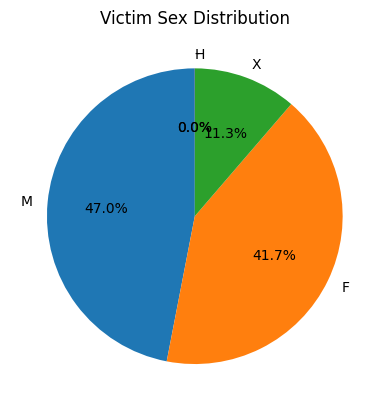

In [36]:
counts = df['victim_sex'].value_counts()
plt.pie(counts, labels=counts.index, autopct='%1.1f%%', startangle=90) # type: ignore
plt.title("Victim Sex Distribution")
plt.show()
plt.show()

In [37]:
df['victim_sex'] = df['victim_sex'].replace(
    {
        'H' : 'Unknown',
        'X' : 'Unknown',
        '-' : 'Unknown'
    }
)
df['victim_sex'] = df['victim_sex'].fillna('Unknown')
df['victim_sex'].value_counts()

victim_sex
M          403110
F          358314
Unknown    240505
Name: count, dtype: int64

In [38]:
df['victim_sex'] = df['victim_sex'].astype('category')

In [39]:
df['victim_sex'].isna().sum()

0

In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1001929 entries, 0 to 1004893
Data columns (total 30 columns):
 #   Column                    Non-Null Count    Dtype         
---  ------                    --------------    -----         
 0   reported_date             1001929 non-null  datetime64[ns]
 1   date_occurrence           1001929 non-null  datetime64[ns]
 2   area_code                 1001929 non-null  int8          
 3   area_name                 1001929 non-null  category      
 4   reported_district_number  1001929 non-null  int32         
 5   crime_part                1001929 non-null  bool          
 6   crime_code                1001929 non-null  int64         
 7   crime_code_description    1001929 non-null  string        
 8   Mocodes                   851580 non-null   object        
 9   victim_age                734980 non-null   Int8          
 10  victim_sex                1001929 non-null  category      
 11  victim_descent            858500 non-null   object     

#### Observations
- `victim_sex` contains 5 distinct values: `M` (Male), `F` (Female), `H`, `X`, and `-`. Only `M` and `F` are valid, meaningful categories.
- `H`, `X`, and `-` are all non-standard or placeholder codes with no official LAPD definition in the published data dictionary — they are unified under `'Unknown'`. `NaN` values are also filled with `'Unknown'`.
- After cleaning, the column holds only three values: `M`, `F`, `Unknown`. Converting to `category` dtype is appropriate given this low cardinality (~3 values across ~1M rows).
- The pie chart visualisation shows the sex distribution and helps confirm the proportion of unknown values before and after cleaning.


## 13 — Fill Missing `victim_descent`

In [41]:
df['victim_descent'].value_counts()

victim_descent
H    296060
W    201218
B    135676
X    105780
O     77799
A     21329
K      5990
F      4837
C      4630
J      1584
V      1195
I      1015
Z       577
P       288
U       220
D        91
L        77
G        74
S        58
-         2
Name: count, dtype: int64

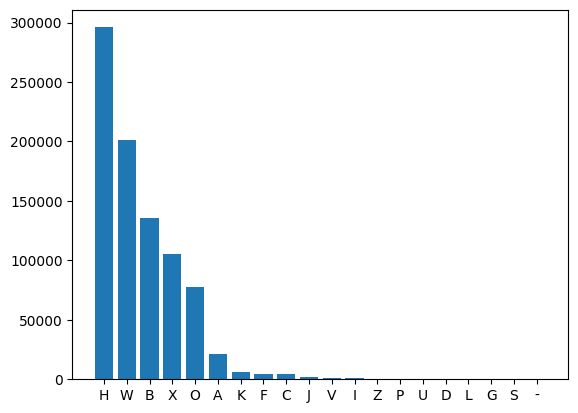

In [42]:
counts = df['victim_descent'].value_counts()
plt.bar(x=counts.index, height=counts)
plt.show()

In [43]:
df['victim_descent'] = df['victim_descent'].replace({'-' : 'X'}) # to be added to Unknown

In [44]:
df['victim_descent'].isna().sum()

143429

In [45]:
df['victim_descent'] = df['victim_descent'].fillna('X')
# changing datatype to category
df['victim_descent'] = df['victim_descent'].astype('category')

In [46]:
df['victim_descent'].value_counts()

victim_descent
H    296060
X    249211
W    201218
B    135676
O     77799
A     21329
K      5990
F      4837
C      4630
J      1584
V      1195
I      1015
Z       577
P       288
U       220
D        91
L        77
G        74
S        58
Name: count, dtype: int64

#### Observations
- `victim_descent` uses single-letter LAPD codes (e.g. `H` = Hispanic, `B` = Black, `W` = White, `X` = Unknown). The dash `-` is a non-standard placeholder that is mapped to `X` (Unknown) for consistency.
- After replacing `-` with `X`, remaining `NaN` values are also filled with `X`. This ensures the column has no missing values and that all unknown descent records are consolidated under one code.
- No new category is invented — `X` is the official LAPD code for "Unknown descent", so this substitution aligns with the data schema.
- The bar chart before and after gives a visual confirmation that the distribution is preserved and no unintended values remain.


## 14 - Premise Code

In [47]:
df['premise_code'].value_counts().head(20)

premise_code
101.0    260187
501.0    163522
502.0    118912
108.0     68758
203.0     47506
102.0     40768
122.0     29280
707.0     19263
104.0     16020
404.0     14381
210.0     12281
123.0      8213
710.0      8022
402.0      7873
504.0      7552
103.0      7049
109.0      6632
405.0      6190
121.0      6174
301.0      5737
Name: count, dtype: int64

In [48]:
print(f"Missing Values in Premise Code: {df['premise_code'].isna().sum()}")

df = df.dropna(subset=['premise_code'])

print(f"Missing Values in Premise Code After Cleaning: {df['premise_code'].isna().sum()}")

print(df['premise_code'].dtypes)

# change datatype to int16 
df['premise_code'] = df['premise_code'].astype('int16')
print(df['premise_code'].dtypes)


Missing Values in Premise Code: 16
Missing Values in Premise Code After Cleaning: 0
float64
int16


In [49]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1001913 entries, 0 to 1004893
Data columns (total 30 columns):
 #   Column                    Non-Null Count    Dtype         
---  ------                    --------------    -----         
 0   reported_date             1001913 non-null  datetime64[ns]
 1   date_occurrence           1001913 non-null  datetime64[ns]
 2   area_code                 1001913 non-null  int8          
 3   area_name                 1001913 non-null  category      
 4   reported_district_number  1001913 non-null  int32         
 5   crime_part                1001913 non-null  bool          
 6   crime_code                1001913 non-null  int64         
 7   crime_code_description    1001913 non-null  string        
 8   Mocodes                   851580 non-null   object        
 9   victim_age                734979 non-null   Int8          
 10  victim_sex                1001913 non-null  category      
 11  victim_descent            1001913 non-null  category   

## 15 - Premise Description

In [50]:
df['premise_description'].value_counts().head(15)

premise_description
STREET                                          260187
SINGLE FAMILY DWELLING                          163522
MULTI-UNIT DWELLING (APARTMENT, DUPLEX, ETC)    118912
PARKING LOT                                      68758
OTHER BUSINESS                                   47506
SIDEWALK                                         40768
VEHICLE, PASSENGER/TRUCK                         29280
GARAGE/CARPORT                                   19263
DRIVEWAY                                         16020
DEPARTMENT STORE                                 14381
RESTAURANT/FAST FOOD                             12281
PARKING UNDERGROUND/BUILDING                      8213
OTHER PREMISE                                     8022
MARKET                                            7873
OTHER RESIDENCE                                   7552
Name: count, dtype: int64

In [51]:
print(f"Missing Values of Premise Description: {df['premise_description'].isna().sum()}")

df['premise_description'] = df['premise_description'].fillna('Unknown')
# chaning datatype to string[pyarrow]
df['premise_description'] = df['premise_description'].astype('string[pyarrow]')


Missing Values of Premise Description: 571


In [52]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1001913 entries, 0 to 1004893
Data columns (total 30 columns):
 #   Column                    Non-Null Count    Dtype         
---  ------                    --------------    -----         
 0   reported_date             1001913 non-null  datetime64[ns]
 1   date_occurrence           1001913 non-null  datetime64[ns]
 2   area_code                 1001913 non-null  int8          
 3   area_name                 1001913 non-null  category      
 4   reported_district_number  1001913 non-null  int32         
 5   crime_part                1001913 non-null  bool          
 6   crime_code                1001913 non-null  int64         
 7   crime_code_description    1001913 non-null  string        
 8   Mocodes                   851580 non-null   object        
 9   victim_age                734979 non-null   Int8          
 10  victim_sex                1001913 non-null  category      
 11  victim_descent            1001913 non-null  category   

## 16 Weapon Used Code

In [53]:
print(f"Count of Unique Weapons Code: {df['weapon_used_code'].nunique()}")
print(f"Maximum Value of Weapon Code: {df['weapon_used_code'].max()}")
print(f"Minimum Value of Weapon Code: {df['weapon_used_code'].min()}")
missing_percentage = df['weapon_used_code'].isna().sum() *100 / len(df)
print(f"Percentage of Missing Values: {round(missing_percentage,2)}%")

Count of Unique Weapons Code: 79
Maximum Value of Weapon Code: 516.0
Minimum Value of Weapon Code: 101.0
Percentage of Missing Values: 67.44%


In [54]:
df['weapon_used_code'] = df['weapon_used_code'].fillna(-1).astype('int16')

df['weapon_used_code'].info()

<class 'pandas.core.series.Series'>
Index: 1001913 entries, 0 to 1004893
Series name: weapon_used_code
Non-Null Count    Dtype
--------------    -----
1001913 non-null  int16
dtypes: int16(1)
memory usage: 9.6 MB


## 17 Weapon Description

In [55]:
print(f"Number of Unique Descriptions: {df['weapon_description'].nunique()}")
missing_percentage = round(df['weapon_description'].isna().sum() * 100 / len(df), 2)
print(f"Missing Percentage: {missing_percentage}%")

df['weapon_description'] = df['weapon_description'].fillna("Unknown | N/A").astype('string[pyarrow]')
missing_percentage_after = round(df['weapon_description'].isna().sum() * 100 / len(df), 2)
print(f"Missing Percentage After Cleaning: {missing_percentage}%")
df['weapon_description'].info()

Number of Unique Descriptions: 79
Missing Percentage: 67.44%
Missing Percentage After Cleaning: 67.44%
<class 'pandas.core.series.Series'>
Index: 1001913 entries, 0 to 1004893
Series name: weapon_description
Non-Null Count    Dtype 
--------------    ----- 
1001913 non-null  string
dtypes: string(1)
memory usage: 33.8 MB


## 18 Status

In [56]:
print(f"Number of Unique Values: {df['status'].nunique()}")
print(f"Unique Values: {df['status'].unique()}")
print(f"Missing Values: {df['status'].isna().sum()}")

df['status'].value_counts()

Number of Unique Values: 6
Unique Values: ['IC' 'AO' 'AA' 'JA' 'JO' 'CC']
Missing Values: 0


status
IC    800330
AO    109649
AA     86789
JA      3267
JO      1872
CC         6
Name: count, dtype: int64

In [57]:
# changing datatype to category
df['status'] = df['status'].astype('category')

df['status'].info()

<class 'pandas.core.series.Series'>
Index: 1001913 entries, 0 to 1004893
Series name: status
Non-Null Count    Dtype   
--------------    -----   
1001913 non-null  category
dtypes: category(1)
memory usage: 8.6 MB


In [58]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1001913 entries, 0 to 1004893
Data columns (total 30 columns):
 #   Column                    Non-Null Count    Dtype         
---  ------                    --------------    -----         
 0   reported_date             1001913 non-null  datetime64[ns]
 1   date_occurrence           1001913 non-null  datetime64[ns]
 2   area_code                 1001913 non-null  int8          
 3   area_name                 1001913 non-null  category      
 4   reported_district_number  1001913 non-null  int32         
 5   crime_part                1001913 non-null  bool          
 6   crime_code                1001913 non-null  int64         
 7   crime_code_description    1001913 non-null  string        
 8   Mocodes                   851580 non-null   object        
 9   victim_age                734979 non-null   Int8          
 10  victim_sex                1001913 non-null  category      
 11  victim_descent            1001913 non-null  category   

## 19 Status Description

In [59]:
print(f"Unique Values: {df['status_description'].nunique()}")
print(f"Values: {df['status_description'].unique()}")
print(f"Missing Values: {df['status_description'].isna().sum()}")

Unique Values: 6
Values: ['Invest Cont' 'Adult Other' 'Adult Arrest' 'Juv Arrest' 'Juv Other' 'UNK']
Missing Values: 0


In [60]:
status_mapping = {
    'Invest Cont': 'Investigation Continues',
    'Adult Other': 'Adult Other',
    'Adult Arrest': 'Adult Arrest',
    'Juv Arrest': 'Juvenile Arrest',
    'Juv Other': 'Juvenile Other',
    'UNK': 'Unknown'
}

df['status_description'] = df['status_description'].replace(status_mapping)

In [61]:
df['status_description'] = df['status_description'].astype('category')
df['status_description'].info()

<class 'pandas.core.series.Series'>
Index: 1001913 entries, 0 to 1004893
Series name: status_description
Non-Null Count    Dtype   
--------------    -----   
1001913 non-null  category
dtypes: category(1)
memory usage: 8.6 MB


## 20 - Crime Code 1

In [62]:
print(f"Unique Values: {df['crime_code_1'].nunique()}")
print(f"Missing Values: {df['crime_code_1'].isna().sum()}")

Unique Values: 142
Missing Values: 11


In [63]:
df['crime_code_1'].value_counts()

crime_code_1
510.0    114246
624.0     75055
330.0     63556
354.0     62526
740.0     61145
          ...  
430.0         4
884.0         4
445.0         4
926.0         1
453.0         1
Name: count, Length: 142, dtype: int64

In [64]:
df = df.dropna(subset=['crime_code_1'])

before = len(df)

df = df.dropna(subset=['crime_code_1', 'premise_code'])

after = len(df)

print("Dropped %:", (before-after)/before * 100)

Dropped %: 0.0


In [65]:
df['crime_code_1'].info()

<class 'pandas.core.series.Series'>
Index: 1001902 entries, 0 to 1004893
Series name: crime_code_1
Non-Null Count    Dtype  
--------------    -----  
1001902 non-null  float64
dtypes: float64(1)
memory usage: 15.3 MB


In [66]:
print(f"Maximum Value: {df['crime_code_1'].max()}")
print(f"Minimum Value: {df['crime_code_1'].min()}")

df['crime_code_1'] = df['crime_code_1'].astype('int16')

df['crime_code_1'].info()

Maximum Value: 956.0
Minimum Value: 110.0
<class 'pandas.core.series.Series'>
Index: 1001902 entries, 0 to 1004893
Series name: crime_code_1
Non-Null Count    Dtype
--------------    -----
1001902 non-null  int16
dtypes: int16(1)
memory usage: 9.6 MB


## 21 - Crime Code 2

In [67]:
print(f"Unique Values: {df['crime_code_2'].nunique()}")
missing_percentage = df['crime_code_2'].isna().sum() * 100 / len(df)
print(f"Missing Values: {round(missing_percentage ,2)}")

Unique Values: 126
Missing Values: 93.11


## 22 - Crime Code 3

In [68]:
print(f"Unique Values: {df['crime_code_3'].nunique()}")
missing_percentage = df['crime_code_3'].isna().sum() * 100 / len(df)
print(f"Missing Values: {round(missing_percentage ,2)}")

Unique Values: 38
Missing Values: 99.77


## 23 - Crime Code 4

In [69]:
print(f"Unique Values: {df['crime_code_4'].nunique()}")
missing_percentage = df['crime_code_4'].isna().sum() * 100 / len(df)
print(f"Missing Values: {round(missing_percentage ,2)}")

Unique Values: 6
Missing Values: 99.99


In [70]:
# dropping crime code columns 
df.drop(columns=['crime_code_2', 'crime_code_3', 'crime_code_4'], inplace=True)

In [71]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1001902 entries, 0 to 1004893
Data columns (total 27 columns):
 #   Column                    Non-Null Count    Dtype         
---  ------                    --------------    -----         
 0   reported_date             1001902 non-null  datetime64[ns]
 1   date_occurrence           1001902 non-null  datetime64[ns]
 2   area_code                 1001902 non-null  int8          
 3   area_name                 1001902 non-null  category      
 4   reported_district_number  1001902 non-null  int32         
 5   crime_part                1001902 non-null  bool          
 6   crime_code                1001902 non-null  int64         
 7   crime_code_description    1001902 non-null  string        
 8   Mocodes                   851569 non-null   object        
 9   victim_age                734973 non-null   Int8          
 10  victim_sex                1001902 non-null  category      
 11  victim_descent            1001902 non-null  category   

## 24 Location

In [72]:
print(f"Missing Values: {df['location'].isna().sum()}")
print(f"Unique Values Count: {df['location'].nunique()}")

Missing Values: 0
Unique Values Count: 66566


In [73]:
# Remove spaces and make all in lowercase
df['location'] = df['location'].str.strip().str.lower()

# remove extra spaces
df['location'] = df['location'].str.replace(r'\s+', ' ', regex=True)

# Check Unique Values after cleaning 
print(f"Unique Values Count: {df['location'].nunique()}")

# change datatype to category
df['location'] = df['location'].astype('category')

df['location'].info()

Unique Values Count: 66467
<class 'pandas.core.series.Series'>
Index: 1001902 entries, 0 to 1004893
Series name: location
Non-Null Count    Dtype   
--------------    -----   
1001902 non-null  category
dtypes: category(1)
memory usage: 14.0 MB


In [74]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1001902 entries, 0 to 1004893
Data columns (total 27 columns):
 #   Column                    Non-Null Count    Dtype         
---  ------                    --------------    -----         
 0   reported_date             1001902 non-null  datetime64[ns]
 1   date_occurrence           1001902 non-null  datetime64[ns]
 2   area_code                 1001902 non-null  int8          
 3   area_name                 1001902 non-null  category      
 4   reported_district_number  1001902 non-null  int32         
 5   crime_part                1001902 non-null  bool          
 6   crime_code                1001902 non-null  int64         
 7   crime_code_description    1001902 non-null  string        
 8   Mocodes                   851569 non-null   object        
 9   victim_age                734973 non-null   Int8          
 10  victim_sex                1001902 non-null  category      
 11  victim_descent            1001902 non-null  category   

## 25 - Cross Street 

In [75]:
print(f"Percentage of missing values: {round(df['cross_street'].isna().sum() * 100 / len(df),2)}")

df.drop(columns=['cross_street'], inplace=True)

Percentage of missing values: 84.65


## 26 - Longitude

In [76]:
print(f"Percentage of missing values: {round(df['longitude'].isna().sum() * 100 / len(df),2)}")
# the valid range -180 to +180
df['longitude'].value_counts().head(15)


Percentage of missing values: 0.0


longitude
-118.2739    7525
-118.2827    6407
-118.2915    4280
-118.2652    4245
-118.2871    3909
-118.3089    3859
-118.2783    3740
-118.2916    3722
-118.3090    3620
-118.4662    2714
-118.2695    2646
-118.3002    2561
-118.2870    2508
-118.3965    2505
-118.2375    2489
Name: count, dtype: int64

In [77]:
print(f"Maximum: {df['longitude'].max()}")
print(f"Minimum: {df['longitude'].min()}")

invalid_mask_longitude = (
    (df['longitude'] < -180) |
    (df['longitude'] > 180)
)
df[invalid_mask_longitude]

Maximum: 0.0
Minimum: -118.6676


,reported_date,date_occurrence,area_code,area_name,reported_district_number,crime_part,crime_code,crime_code_description,Mocodes,victim_age,victim_sex,victim_descent,premise_code,premise_description,weapon_used_code,weapon_description,status,status_description,crime_code_1,location,latitude,longitude,hour_occurrence,minute_occurrence,victim_age_status,victim_age_valid


In [78]:
df['longitude'] = df['longitude'].astype('float32')
df['longitude'].info()

<class 'pandas.core.series.Series'>
Index: 1001902 entries, 0 to 1004893
Series name: longitude
Non-Null Count    Dtype  
--------------    -----  
1001902 non-null  float32
dtypes: float32(1)
memory usage: 11.5 MB


## 27 Latitude

In [79]:
print(f"Percentage of missing values: {round(df['latitude'].isna().sum() * 100 / len(df),2)}")
# the valid range -180 to +180
df['latitude'].value_counts().head(15)

Percentage of missing values: 0.0


latitude
34.1016    5684
34.2012    4499
34.0980    4255
34.1939    3538
34.1867    3294
33.9455    3140
34.0561    2996
34.1649    2957
34.0473    2868
34.1903    2700
34.1938    2611
34.0998    2592
34.0636    2484
34.1576    2452
34.0736    2440
Name: count, dtype: int64

In [80]:
print(f"Maximum: {df['latitude'].max()}")
print(f"Minimum: {df['latitude'].min()}")

invalid_mask_latitude = (
    (df['latitude'] < -180) |
    (df['latitude'] > 180)
)
df[invalid_mask_latitude]

Maximum: 34.3343
Minimum: 0.0


,reported_date,date_occurrence,area_code,area_name,reported_district_number,crime_part,crime_code,crime_code_description,Mocodes,victim_age,victim_sex,victim_descent,premise_code,premise_description,weapon_used_code,weapon_description,status,status_description,crime_code_1,location,latitude,longitude,hour_occurrence,minute_occurrence,victim_age_status,victim_age_valid


In [81]:
df['latitude'] = df['latitude'].astype('float32')
df['latitude'].info()

<class 'pandas.core.series.Series'>
Index: 1001902 entries, 0 to 1004893
Series name: latitude
Non-Null Count    Dtype  
--------------    -----  
1001902 non-null  float32
dtypes: float32(1)
memory usage: 11.5 MB


In [82]:
# to be in Los Angeles Bounds 

df = df[
    df['latitude'].between(33, 35) &
    df['longitude'].between(-119, -117)
]

In [85]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 999665 entries, 0 to 1004893
Data columns (total 25 columns):
 #   Column                    Non-Null Count   Dtype         
---  ------                    --------------   -----         
 0   reported_date             999665 non-null  datetime64[ns]
 1   date_occurrence           999665 non-null  datetime64[ns]
 2   area_code                 999665 non-null  int8          
 3   area_name                 999665 non-null  category      
 4   reported_district_number  999665 non-null  int32         
 5   crime_part                999665 non-null  bool          
 6   crime_code                999665 non-null  int64         
 7   crime_code_description    999665 non-null  string        
 8   Mocodes                   849456 non-null  object        
 9   victim_age                733282 non-null  Int8          
 10  victim_sex                999665 non-null  category      
 11  victim_descent            999665 non-null  category      
 12  premis

In [84]:
# Longtiude and Latitude covers it 
df.drop(columns=['location'], inplace=True)

In [ ]:
df.drop(columns=['victim_age_valid'], inplace=True)

In [88]:
# crimes where ALL records have no victim age = structural no-victim crimes
null_rate = (
    df.groupby('crime_code_description')['victim_age']
    .apply(lambda x: x.isna().mean())
)

# flag crimes where null rate is above a threshold (e.g. 90%)
no_victim_crimes = null_rate[null_rate >= 0.90].index

no_victim_mask = df['crime_code_description'].isin(no_victim_crimes)

print(f"No-victim crime types identified: {len(no_victim_crimes)}")
print(null_rate[null_rate >= 0.90].sort_values(ascending=False).head(20))

No-victim crime types identified: 4
crime_code_description
boat - stolen           1.000000
failure to disperse     1.000000
vehicle - stolen        0.996979
lynching - attempted    0.900000
Name: victim_age, dtype: float64


In [90]:
crime_group_median = (
    df[~no_victim_mask]
    .groupby('crime_code_description')['victim_age']
    .transform('median')
    .round()
    .astype('Int8')  # match the column dtype
)

df.loc[~no_victim_mask, 'victim_age'] = (
    df.loc[~no_victim_mask, 'victim_age'].fillna(crime_group_median)
)

print(f"NaN in victim crimes:    {df.loc[~no_victim_mask, 'victim_age'].isna().sum()}")
print(f"NaN in no-victim crimes: {df.loc[no_victim_mask, 'victim_age'].isna().sum()}")

NaN in victim crimes:    0
NaN in no-victim crimes: 113996


In [91]:
invalid_hour = ~df['hour_occurrence'].between(0, 23)
invalid_minute = ~df['minute_occurrence'].between(0, 59)

print(invalid_hour.sum())
print(invalid_minute.sum())

0
0
